In [87]:
# =========================================================================
# STEP 1 : IMPORTING ESSENTIAL LIBRARIES
#==========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [88]:
#==========================================================================
# STEP 2 : LOADING DATASET
#==========================================================================

df = pd.read_csv('Diwali Sales Data.csv')
print(f'Columns : {df.shape[0]}, Rows : {df.shape[1]}')

Columns : 11251, Rows : 15


In [89]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra?Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [90]:
#==========================================================================
# STEP 3 : FIXING COLUMN HEADERS
#==========================================================================

df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print(df.columns.to_list())

['user_id', 'cust_name', 'product_id', 'gender', 'age_group', 'age', 'marital_status', 'state', 'zone', 'occupation', 'product_category', 'orders', 'amount', 'status', 'unnamed1']


In [91]:
#==========================================================================
# STEP 4: DROPPING COLUMNS
#==========================================================================

df = df.drop(columns=['unnamed1'])
df = df.drop(columns=['status'])


In [92]:
#==========================================================================
# STEP 6 : FIXING MARITAL STATUS
#==========================================================================

df['marital_status'] = df['marital_status'].replace(
    {
    1 : 'Married',
    0 : 'Unmarried'
    }
)

In [93]:
#==========================================================================
# STEP 5 : FINDING CO-RELATIONS FOR MODEL TRAINING
#==========================================================================

numerical_columns = df.select_dtypes(['int64', 'float64'])
print(numerical_columns.head())

   user_id  age  orders   amount
0  1002903   28       1  23952.0
1  1000732   35       3  23934.0
2  1001990   35       3  23924.0
3  1001425   16       2  23912.0
4  1000588   28       2  23877.0


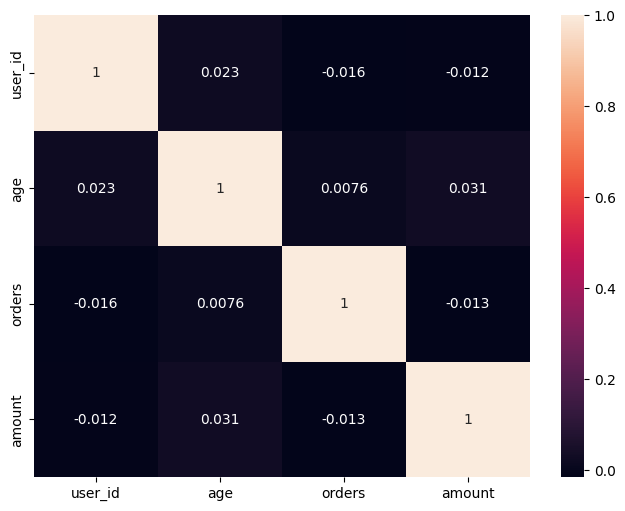

In [94]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [95]:
#==========================================================================
# STEP 7 : EDA
#==========================================================================

In [96]:
df.head()

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Unmarried,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra?Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Unmarried,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


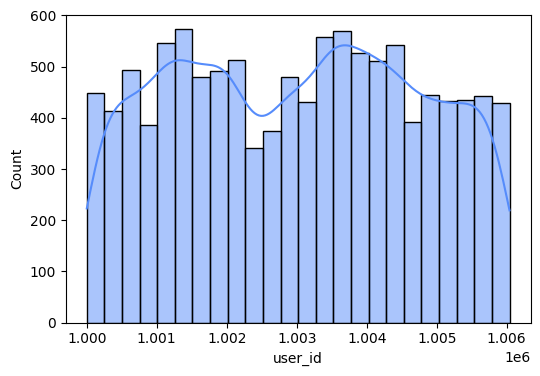

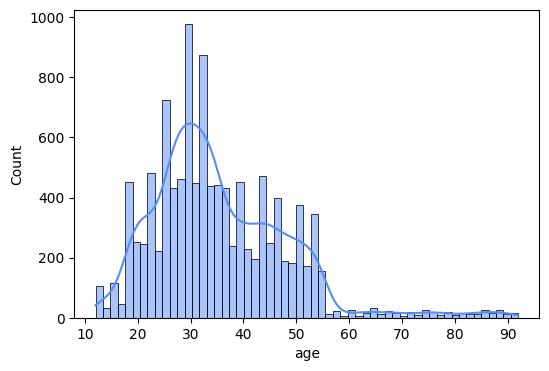

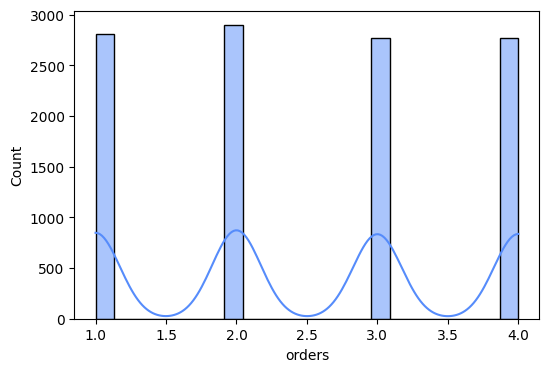

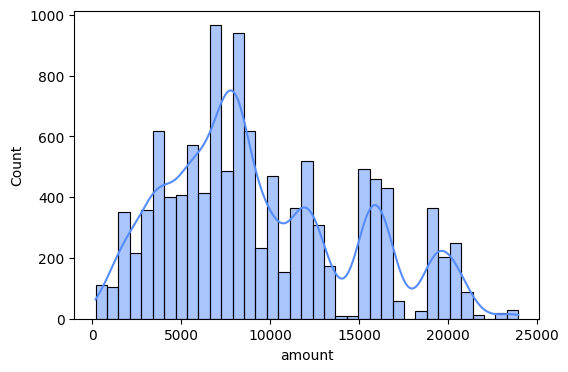

In [97]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde = True)

    # to find distribution of numerical values

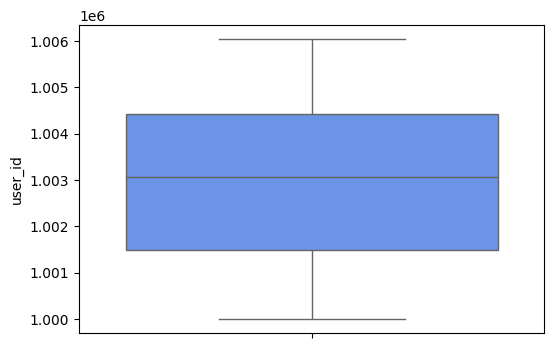

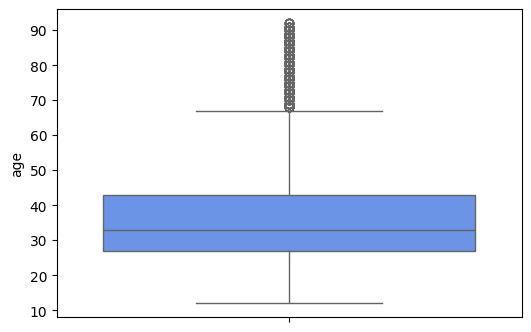

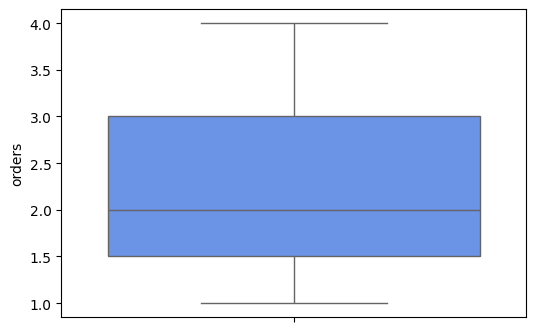

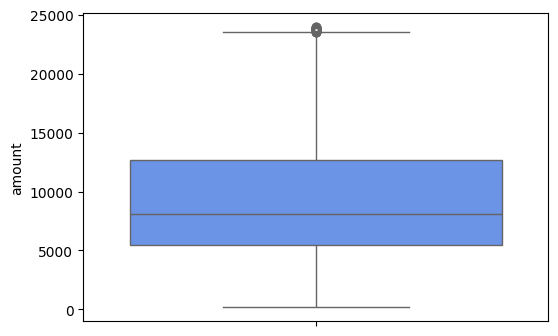

In [98]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df[col])

# help to know bout the spread of the numerical values

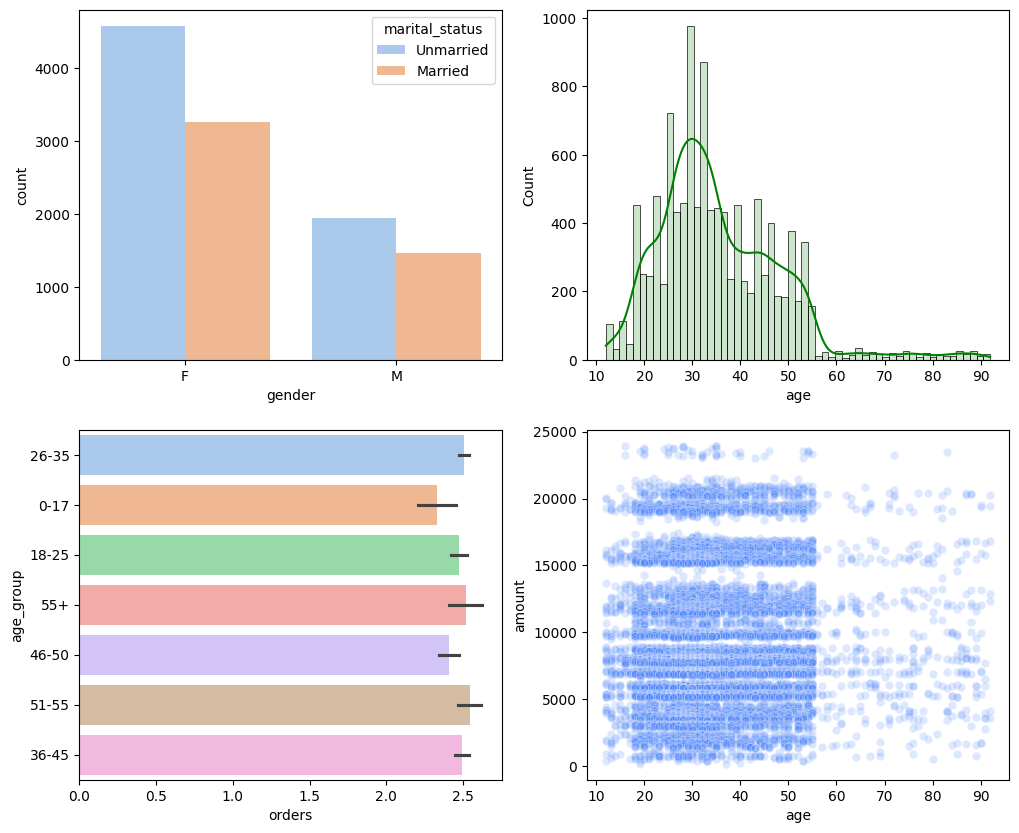

In [99]:
plt.figure(figsize=(12,10))
plt.subplot(2, 2, 1)
sns.countplot(data = df, x = 'gender', hue = 'marital_status', palette = 'pastel')
plt.subplot(2, 2, 2)
sns.histplot(data = df, x = 'age',color = 'green', kde = True, alpha = 0.2)
plt.subplot(2, 2, 3)
sns.barplot(data = df, y = 'age_group', x = 'orders', palette='pastel')
plt.subplot(2, 2, 4)
sns.scatterplot(data = df, x = 'age', y = 'amount', alpha = 0.2)
plt.show()

In [100]:
df.head()

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Unmarried,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra?Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Unmarried,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


In [101]:
df_states = df.groupby('state')['orders'].sum().reset_index()
df_states = df_states.sort_values(by = ['orders'], ascending = False)
# will get to know top ordering states and where is need for attention

df_occupation = df.groupby('occupation')['amount'].sum().reset_index()
df_occupation = df_occupation.sort_values(by = ['amount'], ascending = False)
# will get to know the target occupation and which to target in future to increse sales

# grouped data will help to get info with respect to state a

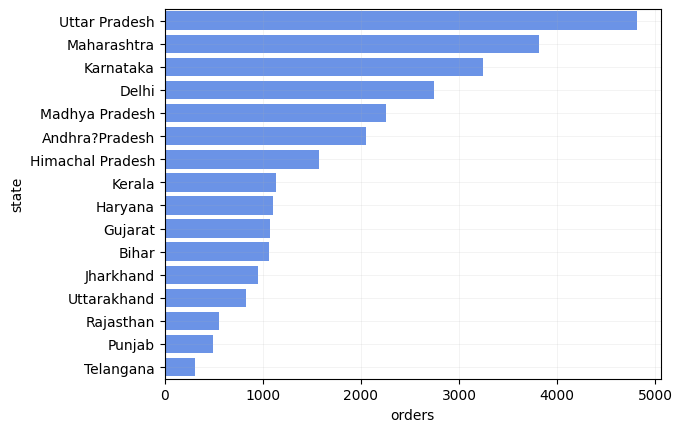

In [102]:
sns.barplot(y='state', x='orders', data=df_states)
plt.grid(alpha = 0.2)
plt.show()

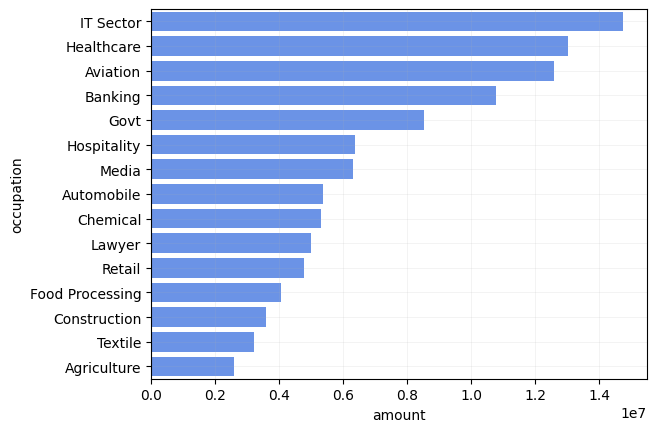

In [103]:
sns.barplot(y='occupation', x='amount', data=df_occupation)
plt.grid(alpha = 0.2)
plt.show()